In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'JD'
train_label = 5
train_end_date = '2025-07-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'JD',
 'contract_multiplier': 5,
 'price_tick': 1,
 'margin_rate': 0.07,
 'fee': 0.0,
 'fee_way': 'number',
 'fee_comment': '平今',
 'trading_hours': ['09:00-11:30', '13:30-15:00'],
 'light': 1,
 'night': 0,
 'exchange': 'dce',
 'name': '鸡蛋'}

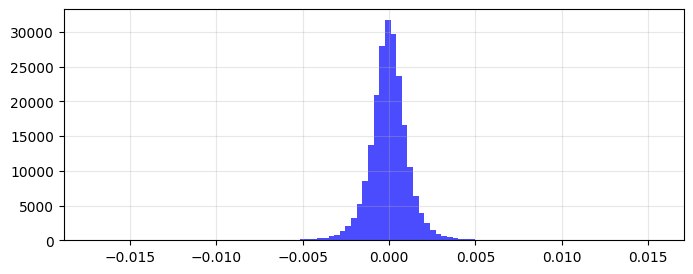

2025-07-01_JD_5


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_C|_CS|_RR|_JD|_LH|_AP|_CJ|_SR|_CF|_CY|C_|CS_|RR_|JD_|LH_|AP_|CJ_|SR_|CF_|CY_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['pred_ret']
特征分布性过滤：
筛选之前因子数量：1885， 筛选之后因子数量：1806

特征重要性过滤： 300 200 	待筛因子个数 1806
无向因子有效个数： 848 有向因子有效个数： 1007
  选择有向特征 236 个，重要性范围: 1711.00 - 24.00
  选择无向特征 138 个，重要性范围: 2209.00 - 63.00

单因子sharpe过滤： 0.5 sp范围-13.2517 ~ 10.6647   待筛因子个数 374

特征相关性性过滤： 300     待筛因子个数 305
  选择特征 262 个, 特征最大相关性0.8975041567669407

已挑选日频开盘因子数量： 5 ['day_first3power', 'day_jump', 'day_first4redcorr', 'day_first10rev', 'day_first4greencorr']

保留日频开盘因子数量： 5 ['day_first3power', 'day_jump', 'day_first4redcorr', 'day_first10rev', 'day_first4greencorr']

排除指定因子后，剩余特征 260 个


(183, 0, 51, 26)

正在从 /mnt/Data/writable/liaoyuyang/factor/JD/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (216142, 1889)
训练集时间范围: 2021-02-02 09:11:00 至 2025-06-30 14:49:00
[200]	valid_0's rmse: 0.994397
[400]	valid_0's rmse: 0.994399
[600]	valid_0's rmse: 0.994412


<Figure size 1000x600 with 0 Axes>

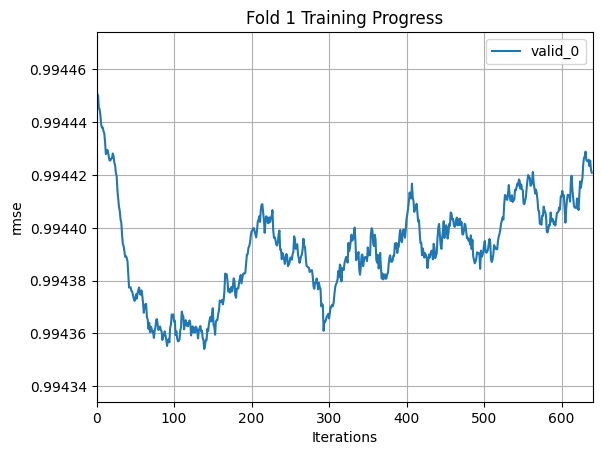

{'train_rmse': np.float64(0.9977325926443734), 'val_rmse': np.float64(0.9999207461469645), 'best_iteration': 140}
test_corr: 0.0305
[200]	valid_0's rmse: 0.994
[400]	valid_0's rmse: 0.993829
[600]	valid_0's rmse: 0.993792
[800]	valid_0's rmse: 0.993837
[1000]	valid_0's rmse: 0.993871


<Figure size 1000x600 with 0 Axes>

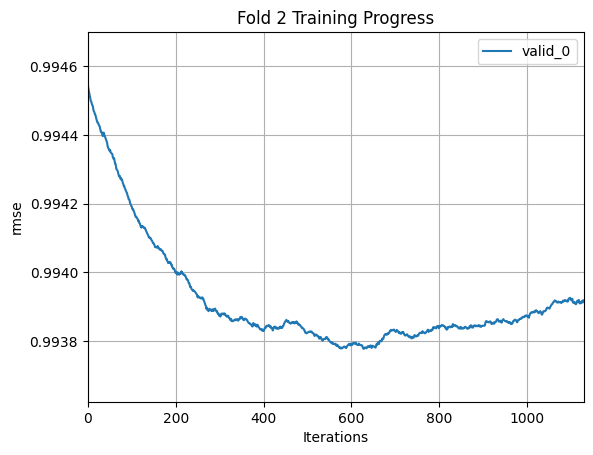

{'train_rmse': np.float64(0.9899226343758855), 'val_rmse': np.float64(0.9993382401392783), 'best_iteration': 629}
test_corr: 0.0231
[200]	valid_0's rmse: 0.993969
[400]	valid_0's rmse: 0.993753
[600]	valid_0's rmse: 0.993624
[800]	valid_0's rmse: 0.993574
[1000]	valid_0's rmse: 0.993572
[1200]	valid_0's rmse: 0.993548
[1400]	valid_0's rmse: 0.993586
[1600]	valid_0's rmse: 0.993637


<Figure size 1000x600 with 0 Axes>

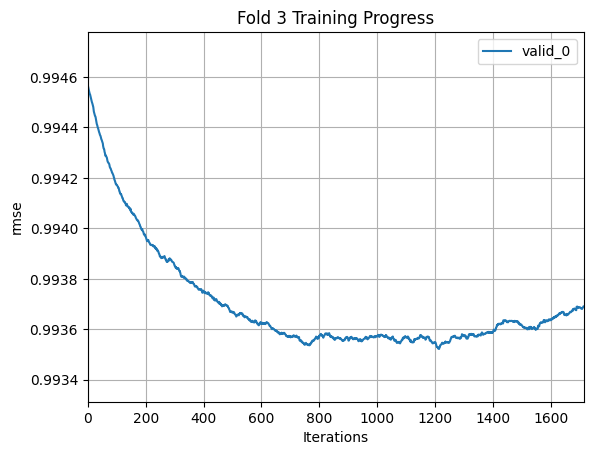

{'train_rmse': np.float64(0.9839717043304055), 'val_rmse': np.float64(0.9990749047717961), 'best_iteration': 1214}
test_corr: 0.0205
[200]	valid_0's rmse: 0.99374
[400]	valid_0's rmse: 0.993436
[600]	valid_0's rmse: 0.993272
[800]	valid_0's rmse: 0.993196
[1000]	valid_0's rmse: 0.99317
[1200]	valid_0's rmse: 0.993127
[1400]	valid_0's rmse: 0.99311
[1600]	valid_0's rmse: 0.993109
[1800]	valid_0's rmse: 0.993122
[2000]	valid_0's rmse: 0.993159


<Figure size 1000x600 with 0 Axes>

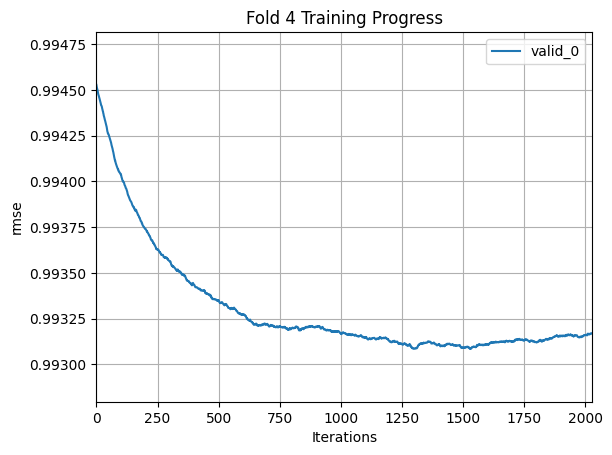

{'train_rmse': np.float64(0.9798916459003262), 'val_rmse': np.float64(0.9986434544228769), 'best_iteration': 1529}
test_corr: 0.0135
[200]	valid_0's rmse: 0.993818
[400]	valid_0's rmse: 0.993658
[600]	valid_0's rmse: 0.993555
[800]	valid_0's rmse: 0.993568
[1000]	valid_0's rmse: 0.993537
[1200]	valid_0's rmse: 0.993587
[1400]	valid_0's rmse: 0.993666


<Figure size 1000x600 with 0 Axes>

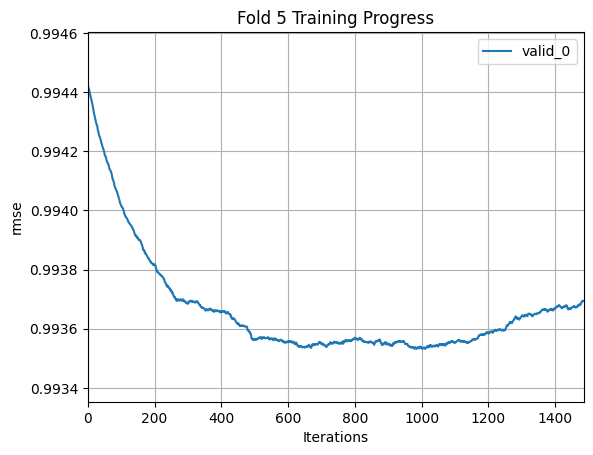

{'train_rmse': np.float64(0.9860571470808698), 'val_rmse': np.float64(0.999093902545832), 'best_iteration': 986}
test_corr: 0.0269


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/JD_pred5_2025-07-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 2_000_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [9]:
bt.mkt_data

,datetime,instrument,open,high,low,close,last_twap,mid_price,volume,turnover,...,spread,bar_count,trade_date,tick10avg,tick0t10avg,tick6t15avg,tick6t60avg,rtn_1,rtn_5,rtn_10
0,2021-02-02 09:01:00,jd2105,4403.0,4409.0,4384.0,4389.0,4391.719577,4391.661708,6734.0,295957820.0,...,1.460317,241,2021-02-02,4403.80,4398.052632,4391.187500,4390.335329,0.000719,-0.001391,0.001264
1,2021-02-02 09:02:00,jd2105,4389.0,4389.0,4375.0,4383.0,4382.231638,4382.271815,2883.0,126333460.0,...,1.254237,239,2021-02-02,4385.75,4385.090909,4384.300000,4381.830189,-0.001628,-0.000313,0.000378
2,2021-02-02 09:03:00,jd2105,4383.0,4390.0,4381.0,4383.0,4384.733333,4384.704026,1354.0,59373140.0,...,1.144444,241,2021-02-02,4382.60,4382.942857,4383.531250,4384.981481,0.001274,0.001867,0.000124
3,2021-02-02 09:04:00,jd2105,4383.0,4384.0,4372.0,4380.0,4378.359551,4378.318667,2254.0,98674160.0,...,1.230337,240,2021-02-02,4382.70,4382.088235,4379.964286,4377.840764,-0.001409,0.001571,-0.002030
4,2021-02-02 09:05:00,jd2105,4379.0,4386.0,4379.0,4385.0,4383.283422,4383.139596,1277.0,55971930.0,...,1.224599,238,2021-02-02,4382.35,4383.029412,4384.058824,4383.417647,-0.000344,0.003434,-0.000505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275495,2026-03-06 14:56:00,jd2605,3392.0,3395.0,3392.0,3394.0,3393.914286,3393.573138,1095.0,37162220.0,...,1.080952,210,2026-03-06,3392.90,3393.488372,3394.282051,3394.021390,-0.000206,0.020306,0.020063
275496,2026-03-06 14:57:00,jd2605,3394.0,3394.0,3392.0,3393.0,3392.901042,3392.868979,838.0,28430890.0,...,1.041667,192,2026-03-06,3393.60,3393.230769,3392.729730,3392.818713,-0.000242,0.018903,0.019434
275497,2026-03-06 14:58:00,jd2605,3393.0,3393.0,3391.0,3393.0,3392.175532,3392.111513,503.0,17062460.0,...,1.069149,188,2026-03-06,3392.45,3392.416667,3392.090909,3392.119048,0.000007,0.018211,0.018772
275498,2026-03-06 14:59:00,jd2605,3391.0,3392.0,3390.0,3392.0,3391.338308,3391.278693,682.0,23127240.0,...,1.024876,201,2026-03-06,3391.75,3391.702703,3391.580645,3391.297753,0.022846,0.021419,0.018443


In [10]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00']


  0%|          | 0/36209 [00:00<?, ?it/s]

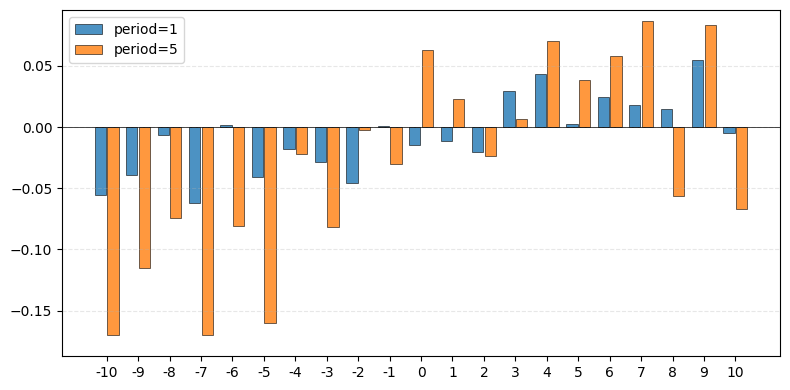

In [11]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-01:00"], g=21)

In [12]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,7311
空头(-1) 数量,7850
空仓(0) 数量,21050
多头占比,20.19%
空头占比,21.68%
空仓占比,58.13%
交易日数量,161
总收益(非年化%),0.86
总交易次数（开平算一次）,1689
日均交易次数（开平算一次）,10.49


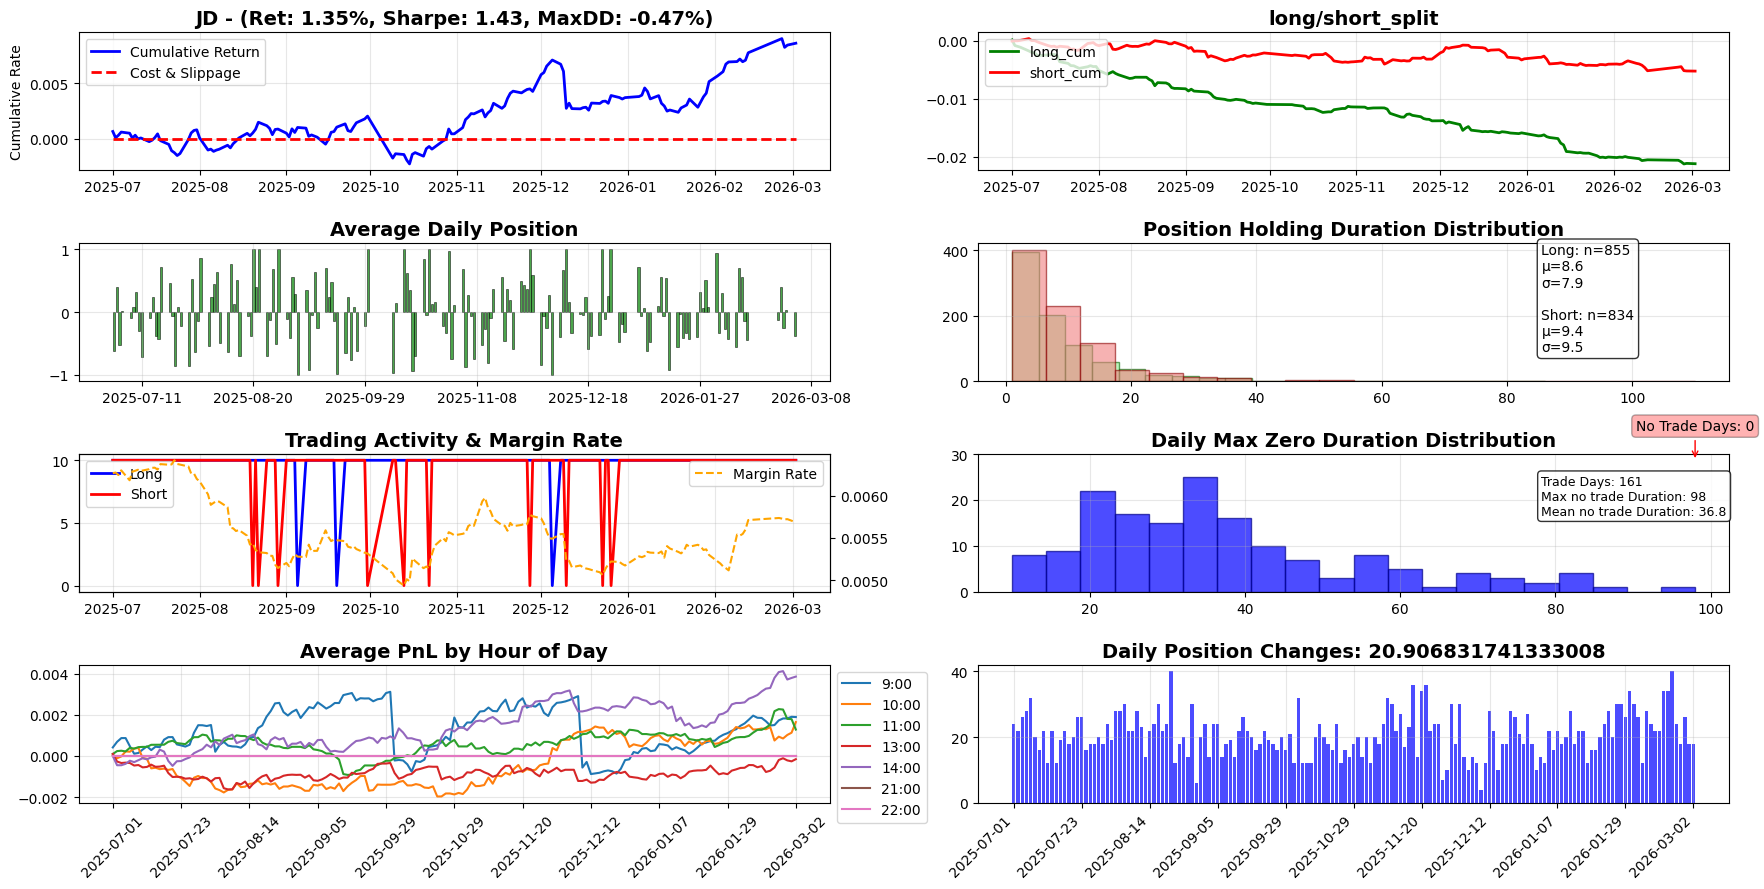

In [13]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [14]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: JD
📅 总交易日数: 161
📊 总数据点: 38962
🎯 使用导航按钮或输入页码进行浏览


In [15]:
bv.plot_yearly_eval(merged_data)